In [1]:
# uncomment the following line to install matplotlib if it is not already installed in your environment
# %pip install matplotlib

import numpy as np              # We'll keep using NumPy to generate the data we plot
import matplotlib.pyplot as plt # The standard convention: import pyplot under the alias plt

print(plt.matplotlib.__version__) # Print the installed version of matplotlib

3.11.1


# Practice Example 2: Plotting Fractals

Following the approach in NumPy's own [Plotting Fractals tutorial](https://numpy.org/numpy-tutorials/tutorial-plotting-fractals/#creating-your-own-fractals), we'll draw **escape-time fractals**, the family that includes the Mandelbrot set. The general recipe, for a starting value $z_0$ and a per-pixel point $p$ on the complex plane:

$$z_{n+1} = \text{get\_next}(z_n, p)$$

and ask: does $|z_n|$ stay bounded forever, or does it "escape" past some radius? Points where it stays bounded (after many iterations) belong to the fractal set; points that escape are colored by *how quickly* they escaped, which is what produces the fractal image. Different choices of the update rule `get_next` and the starting value $z_0$ produce entirely different fractals from the same underlying algorithm, so rather than writing one function tied to the Mandelbrot formula specifically, we'll write one general **helper function** that takes `get_next` as an argument, then reuse it for several different fractals, including ones you invent yourself.

We build this entirely with vectorized NumPy operations (no nested Python loops over every pixel), reusing exactly the `np.meshgrid` idea from the density plots section, but this time treating the grid as complex numbers `p = X + 1j * Y`.

In [2]:
def escape_time_fractal(get_next, width, height, x_range=(-2.0, 2.0), y_range=(-2.0, 2.0),
                         initial_z=0j, max_iter=100, escape_radius=2.0):
    # A general-purpose helper for ANY escape-time fractal.
    #   get_next(z, p): given the current value z and this pixel's point p on the complex plane,
    #                   returns the next z in the sequence. This is the only piece that changes
    #                   between different fractals, everything else below is bookkeeping.
    #   initial_z:      the starting z for every pixel. Pass a fixed complex number (e.g. 0j) to
    #                   start every pixel at the same place (this is what the Mandelbrot set does),
    #                   or pass None to start each pixel's z at its OWN point p (this is what a
    #                   Julia set does instead).
    x = np.linspace(*x_range, width)                    # Real-axis coordinates
    y = np.linspace(*y_range, height)                   # Imaginary-axis coordinates
    X, Y = np.meshgrid(x, y)                             # A grid of coordinates, just like in the contour plots section
    P = X + 1j * Y                                       # Treat the grid as complex numbers p = x + iy

    Z = np.full(P.shape, initial_z, dtype=complex) if initial_z is not None else P.copy()  # Starting z for every pixel
    escape_iter = np.full(P.shape, max_iter, dtype=int)  # Assume "never escapes" (max_iter) until proven otherwise
    still_active = np.ones(P.shape, dtype=bool)          # Which pixels haven't escaped yet

    for i in range(max_iter):
        Z[still_active] = get_next(Z[still_active], P[still_active])  # Update only the pixels still in play
        escaped_now = np.abs(Z) > escape_radius           # Past escape_radius guarantees eventual escape to infinity
        newly_escaped = escaped_now & still_active         # Pixels escaping for the FIRST time on this iteration
        escape_iter[newly_escaped] = i                     # Record how many iterations they took
        still_active &= ~escaped_now                       # Remove them from further consideration

    return escape_iter

# Practice Example 4: The Ikeda Map

The [Ikeda map](https://en.wikipedia.org/wiki/Ikeda_map) is a discrete-time chaotic system, originally used to model the behavior of light in a ring laser cavity. Starting from a point $(x_0, y_0)$, it repeatedly applies:

$$t_n = 0.4 - \frac{6}{1 + x_n^2 + y_n^2}$$
$$x_{n+1} = 1 + u\left(x_n \cos(t_n) - y_n \sin(t_n)\right)$$
$$y_{n+1} = u\left(x_n \sin(t_n) + y_n \cos(t_n)\right)$$

where $u$ is a fixed parameter. For $u$ around 0.9, the orbit never settles down to a fixed point or a simple cycle; instead it wanders forever over a intricate, swirling curve called a **strange attractor**. Since there's no formula for the whole attractor at once, we generate it by brute force: iterate the map many thousands of times from a single starting point, then scatter-plot every single point the orbit visited. The interesting shape only appears once you have enough points, a handful of iterations just looks like a few scattered dots.

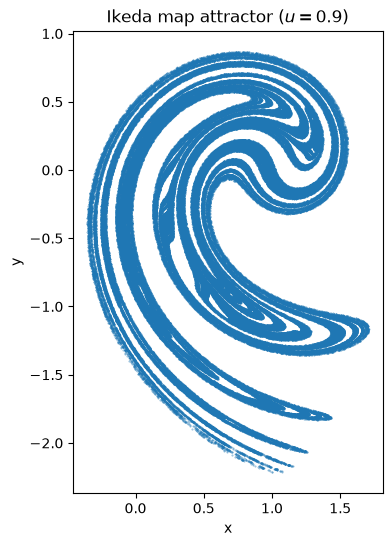

In [3]:
def ikeda_map(u=0.9, n_iter=200000, x0=0.1, y0=0.1):
    x = np.empty(n_iter)   # Pre-allocate: much faster than growing a list one point at a time
    y = np.empty(n_iter)
    x[0], y[0] = x0, y0
    for n in range(n_iter - 1):                                        # Each point depends on the previous one, so this must be a loop, not vectorized
        t = 0.4 - 6 / (1 + x[n]**2 + y[n]**2)
        x[n + 1] = 1 + u * (x[n] * np.cos(t) - y[n] * np.sin(t))
        y[n + 1] = u * (x[n] * np.sin(t) + y[n] * np.cos(t))
    return x, y

x_ikeda, y_ikeda = ikeda_map(u=0.9, n_iter=200000)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_ikeda[200:], y_ikeda[200:], s=0.2, color="tab:blue", alpha=0.5)  # Skip the first 200 points (the transient, before it settles onto the attractor)
ax.set_title(r"Ikeda map attractor ($u = 0.9$)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()

# Practice Exercises

Now it's your turn. For each question, write your own code from scratch, don't just copy a cell above.

### Q1: A single customized plot

Plot $h(x) = x \cdot \sin(x)$ for $x$ from $-10$ to $10$ using at least 500 points. Give the line a color and linewidth of your choice, add a title, x/y axis labels, and turn on the grid. Add a horizontal reference line at $y=0$ using `ax.axhline`.

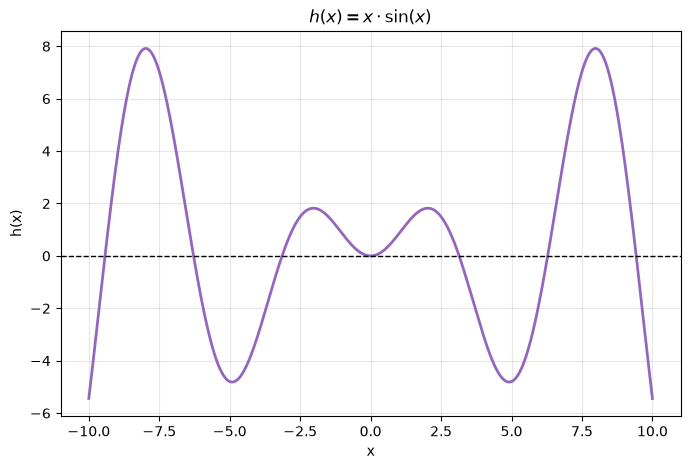

In [4]:
x = np.linspace(-10, 10, 1000)          # 1000 points, well above the required 500
h = x * np.sin(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, h, color="tab:purple", linewidth=2)
ax.axhline(0, color="black", linewidth=1, linestyle="--")   # horizontal reference line at y = 0
ax.set_title(r"$h(x) = x \cdot \sin(x)$")
ax.set_xlabel("x")
ax.set_ylabel("h(x)")
ax.grid(True, alpha=0.3)
plt.show()


### Q2: A 2x3 grid of panels

Using `plt.subplots(nrows=2, ncols=3, ...)`, plot six different transformations of $x$ over $[0, 4\pi]$ in six panels: $\sin(x)$, $\sin(2x)$, $\sin(3x)$, $\cos(x)$, $\cos(2x)$, $\cos(3x)$. Give each panel its own title, and give the whole figure one shared title with `fig.suptitle`.

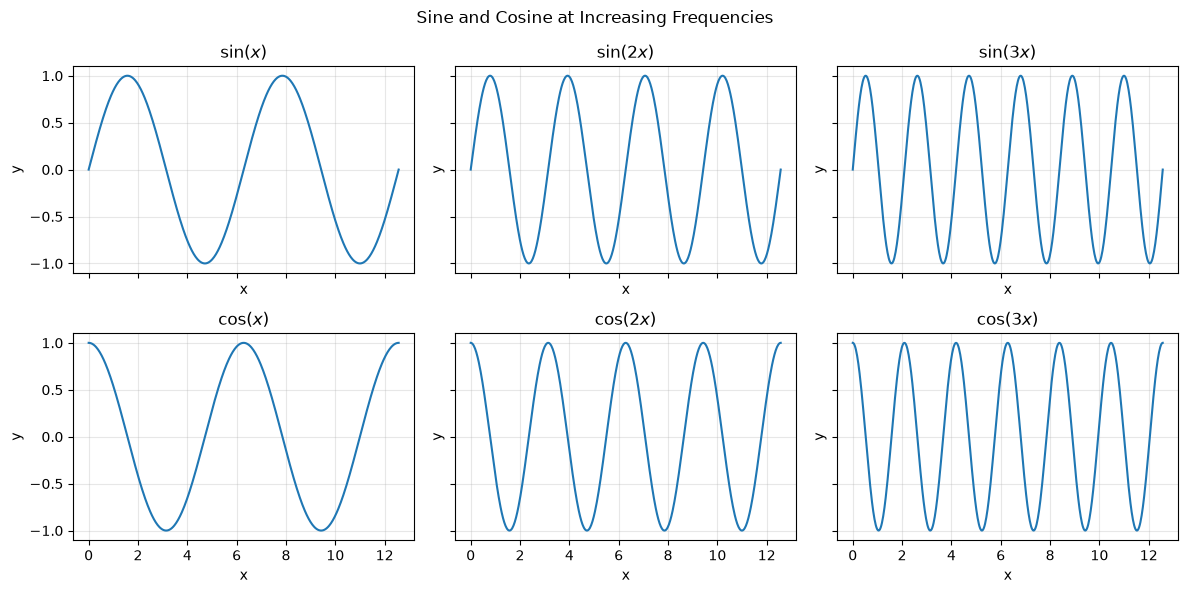

In [5]:
x = np.linspace(0, 4 * np.pi, 500)
funcs = [
    (np.sin(x), r"$\sin(x)$"),
    (np.sin(2 * x), r"$\sin(2x)$"),
    (np.sin(3 * x), r"$\sin(3x)$"),
    (np.cos(x), r"$\cos(x)$"),
    (np.cos(2 * x), r"$\cos(2x)$"),
    (np.cos(3 * x), r"$\cos(3x)$"),
]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
for ax, (y, name) in zip(axs.flatten(), funcs):
    ax.plot(x, y, color="tab:blue")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)

fig.suptitle("Sine and Cosine at Increasing Frequencies")
fig.tight_layout()
plt.show()


### Q3: A contour plot with a well-chosen colormap

Build a grid with `np.meshgrid` over $x, y \in [-2, 2]$ and compute $Z = X^3 - 3X + Y^2$. This function has both positive and negative values with a meaningful zero, so it calls for a *diverging* colormap. Plot it with `ax.contourf`, choosing a diverging colormap (e.g. `"RdBu"` or `"coolwarm"`), and use `TwoSlopeNorm(vcenter=0)` (see the colormaps section) so that zero maps to the center of the colormap. Add a colorbar.

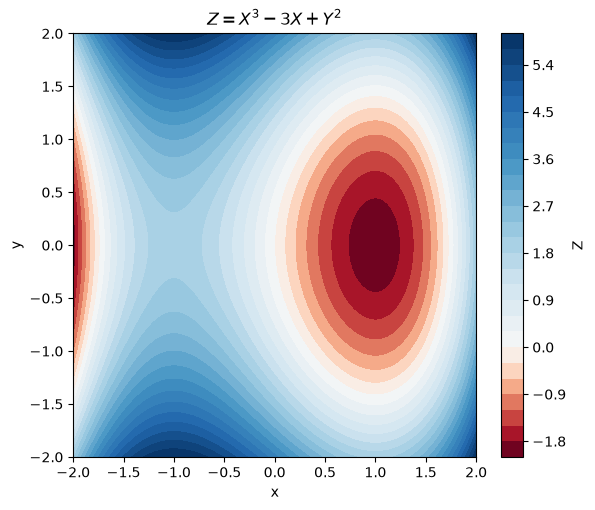

In [6]:
from matplotlib.colors import TwoSlopeNorm

x = np.linspace(-2, 2, 300)
y = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x, y)
Z = X**3 - 3 * X + Y**2                 # both positive and negative values, meaningful zero

norm = TwoSlopeNorm(vcenter=0, vmin=Z.min(), vmax=Z.max())   # center the colormap on Z = 0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cf = ax.contourf(X, Y, Z, levels=30, cmap="RdBu", norm=norm)
fig.colorbar(cf, ax=ax, label="Z")
ax.set_title(r"$Z = X^3 - 3X + Y^2$")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


### Q4: Your own animated GIF

Pick any function `f(x, t)` that depends on both `x` and a time-like parameter `t` (for example, a wave whose amplitude grows and shrinks: `np.sin(x - t) * (1 + 0.5 * np.sin(t / 5))`). Animate it over at least 60 frames and save it as a `.gif` using `FuncAnimation` and `PillowWriter`, following the pattern from Practice Example 3. Display the resulting GIF in the notebook with `IPython.display.Image`.

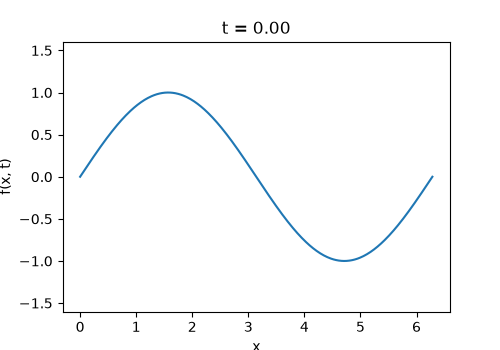

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

x_q4 = np.linspace(0, 2 * np.pi, 400)

def f(x, t):
    # A wave whose amplitude grows and shrinks over time
    return np.sin(x - t) * (1 + 0.5 * np.sin(t / 5))

fig, ax = plt.subplots(figsize=(5, 3.5))
line, = ax.plot(x_q4, f(x_q4, 0), color="tab:blue")
ax.set_ylim(-1.6, 1.6)
ax.set_xlabel("x")
ax.set_ylabel("f(x, t)")

def update(frame):
    t = frame * 0.15
    line.set_ydata(f(x_q4, t))
    ax.set_title(f"t = {t:.2f}")
    return line,

anim = FuncAnimation(fig, update, frames=80, interval=50)
anim.save("q4_breathing_wave.gif", writer=PillowWriter(fps=20))
plt.close(fig)

Image(filename="q4_breathing_wave.gif")


### Q5: Exploring the Ikeda map's parameter

Reuse the `ikeda_map` function from Practice Example 4. Using `plt.subplots(nrows=2, ncols=2, ...)`, plot the attractor for four different values of $u$: `0.6`, `0.7`, `0.8`, and `0.9`, one value per panel (keep `n_iter` at 200,000 or more so each attractor is fully filled in). Give each panel a title showing its `u` value. In a short markdown cell below your plot, describe in a sentence or two how the shape of the attractor changes as `u` increases.

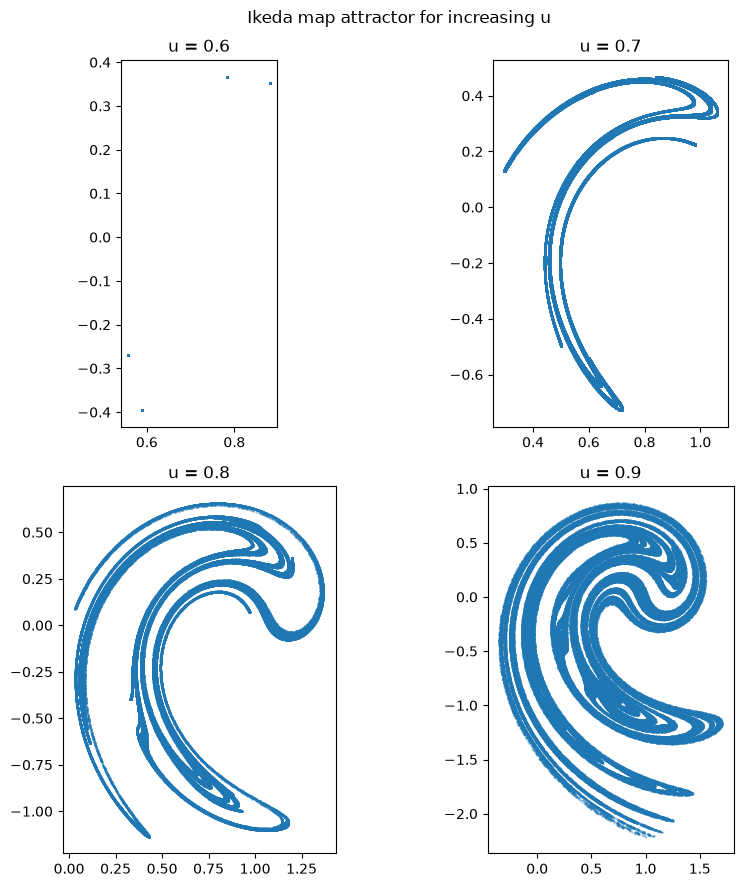

In [8]:
u_values = [0.6, 0.7, 0.8, 0.9]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
for ax, u in zip(axs.flatten(), u_values):
    xu, yu = ikeda_map(u=u, n_iter=200000)
    ax.scatter(xu[200:], yu[200:], s=0.2, color="tab:blue", alpha=0.5)
    ax.set_title(f"u = {u}")
    ax.set_aspect("equal")

fig.suptitle("Ikeda map attractor for increasing u")
fig.tight_layout()
plt.show()


### Q6: Design your own fractal

Reuse the `escape_time_fractal` helper from Practice Example 2. Write your own `get_next(z, p)` function, it doesn't have to be a polynomial; things like `np.sin(z) + p`, `z**4 + p`, or `1 / z**2 + p` are all worth trying. Pick your own `x_range`/`y_range` (you may need to experiment to find a window where something interesting is visible) and a colormap of your choice. Plot the result, then in a short markdown cell below, note which `get_next` you tried and briefly describe the shape it produced.

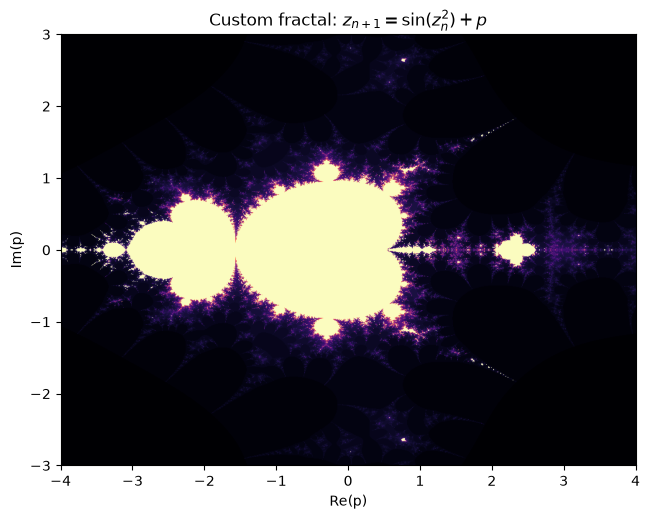

In [9]:
# Custom update rule: z_{n+1} = sin(z_n) + p
def sine_get_next(z, p):
    return np.sin(z**2) + p

counts = escape_time_fractal(
    sine_get_next, width=800, height=800,
    x_range=(-2.0, 2.0), y_range=(-2.0, 2.0), max_iter=60, escape_radius=10.0,
)

fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.imshow(counts, extent=[-4.0, 4.0, -3.0, 3.0], cmap="magma")
ax.set_title(r"Custom fractal: $z_{n+1} = \sin(z_n^2) + p$")
ax.set_xlabel("Re(p)")
ax.set_ylabel("Im(p)")
plt.show()
